### Installation

In [1]:
%%capture
!pip install unsloth

## Unsloth

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
]
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2.5-VL-3B-Instruct-unsloth-bnb-4bit",
    # "unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-04-18 18:00:26.119643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744999226.404295      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744999226.480311      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Unsloth: Failed to patch Gemma3ForConditionalGeneration.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.3.19: Fast Qwen2_5_Vl patching. Transformers: 4.51.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.69G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/267 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

## Data Prep

In [11]:
from datasets import load_dataset
train_dataset = load_dataset("ikram98ai/invoice_img2json",split="train")
test_dataset = load_dataset("ikram98ai/invoice_img2json",split="test")

In [12]:
train_dataset, test_dataset

(Dataset({
     features: ['image', 'json'],
     num_rows: 27
 }),
 Dataset({
     features: ['image', 'json'],
     num_rows: 3
 }))

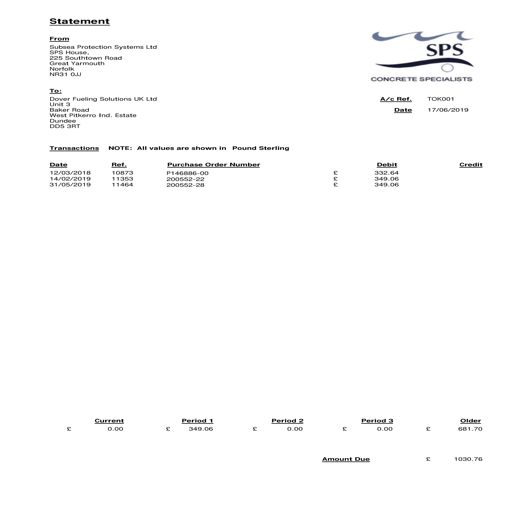

In [13]:
train_dataset[0]['image'].resize((512,512))

In [14]:
train_dataset[0]["json"]

{'Closing Balance': 1030.76,
 'Transactions': [{'Amount': 332.64,
   'Balance': 332.64,
   'Date': '2018-03-12',
   'Ref': '10873',
   'Type': 'invoice'},
  {'Amount': 349.06,
   'Balance': 349.06,
   'Date': '2019-02-14',
   'Ref': '11353',
   'Type': 'invoice'},
  {'Amount': 349.06,
   'Balance': 349.06,
   'Date': '2019-05-31',
   'Ref': '11464',
   'Type': 'invoice'}]}

### Testing Prompt

Before we do any finetuning Let's first see what the model outputs for the first example!

In [41]:
def extract_json(image, model, instruction):
    FastVisionModel.for_inference(model) # Enable for inference!

    messages = [
        {"role": "user", "content": [
            {"type": "text", "text": instruction},
            {"type": "image"}
        ]}
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")
    
    from transformers import TextStreamer
    text_streamer = TextStreamer(tokenizer, skip_prompt = True)
    _ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                       use_cache = True, temperature = 1.5, min_p = 0.1)

In [16]:
image = train_dataset[0]["image"].resize((512,512))


# User prompt that combines the user query and the schema
instruction1 = """You are an expert Invoice data extractor.
Create an invoice json based on the provided image.
Only return Closing Balance (total balance which can be null) and
a list of transctions with Date, Type, Ref, Amount, and Balance.
The invoice data should be in JSON format.
"""

extract_json(image, model, instruction1)

```json
{
  "Closing Balance": {
    "Total Balance": 1030.76
  },
  "Transactions": [
    {
      "Date": "12/03/2018",
      "Type": "Credit",
      "Ref": "14973",
      "Amount": 349.06,
      "Balance": 349.06
    },
    {
      "Date": "14/02/2019",
      "Type": "Credit",
      "Ref": "11533",
      "Amount": 349.06,
      "Balance": 681.76
    },
    {
      "Date": "31/05/2019",
      "Type": "Credit",
      "Ref": "11464",
      "Amount": 349.06,
      "Balance": 1030.76
    }
  ]
}
```<|im_end|>


Impresive result for maintaining the format, but the data is not correct. 

In [17]:
# User prompt that combines the user query and the schema
instruction2 = """You are a Vision Language Model specialized in extacting data in json format from invoice images.
Your task is to analyze the provided invoice image and generate correctly formatted json.
The invoice include a closing balance and a list of transctions with Date, Type, Ref, Amount, and Balance.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation."""

extract_json(image, model, instruction2)

```json
{
  "invoice": {
    "from": {
      "company_name": "Subbase Protection Systems Ltd",
      "address": "SP House, 100 Great Yarmouth Road, Great Yarmouth, Norfolk, NR31 0JU"
    },
    "to": {
      "company_name": "Dover Fueling Solutions UK Ltd",
      "address": "Unit 9, Great Road, Great Yarmouth Industrial Estate, Blythburgh, Suffolk, IP38 3RT"
    },
    "date": "17/06/2019",
    "transactions": [
      {
        "date": "12/03/2018",
        "ref": "146588-00",
        "type": "Purchasing",
        "amount": 320.00,
        "balance": 349.06
      },
      {
        "date": "14/02/2019",
        "ref": "11353",
        "type": "Purchasing",
        "amount": 349.06,
        "balance": 349.06
      },
      {
        "date": "31/05/2019",
        "ref": "11464",
        "type": "Purchasing",
        "amount": 349.06,
        "balance": 349.06
      }
    ],
    "closing_balance": 349.06,
    "total_amount_due": 1030.76
  }
}
```<|im_end|>


### Formatting Dataset

Converting the dataset into the "correct" format for finetuning:

In [20]:

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction1},
            {"type" : "image", "image" : sample["image"].resize((512,512))} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["json"]} ]
        },
    ]
    return { "messages" : conversation }

In [21]:
converted_dataset = [convert_to_conversation(sample) for sample in train_dataset]

In [24]:
converted_test_dataset = [convert_to_conversation(sample) for sample in test_dataset]

Structured conversations of first example:

In [22]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are an expert Invoice data extractor.\nCreate an invoice json based on the provided image.\nOnly return Closing Balance (total balance which can be null) and\na list of transctions with Date, Type, Ref, Amount, and Balance.\nThe invoice data should be in JSON format.\n'},
    {'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=512x512>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': {'Closing Balance': 1030.76,
      'Transactions': [{'Amount': 332.64,
        'Balance': 332.64,
        'Date': '2018-03-12',
        'Ref': '10873',
        'Type': 'invoice'},
       {'Amount': 349.06,
        'Balance': 349.06,
        'Date': '2019-02-14',
        'Ref': '11353',
        'Type': 'invoice'},
       {'Amount': 349.06,
        'Balance': 349.06,
        'Date': '2019-05-31',
        'Ref': '11464',
        'Type': 'invoice'}]}}]}]}

In [23]:
# To check model size
model.get_memory_footprint()/1024/1024

3639.3606719970703

## Training model

We use the new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [25]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    eval_dataset = converted_test_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 15,
        # num_train_epochs = 2, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 4,
        max_seq_length = 4096,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [26]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
3.996 GB of memory reserved.


In [27]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 27 | Num Epochs = 15 | Total steps = 15
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,084,928/3,000,000,000 (1.37% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.630400
2,0.778200
3,0.723700
4,0.532600
5,0.470100
6,0.554800
7,0.433300
8,0.382600
9,0.340500
10,0.421300


In [28]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1057.9216 seconds used for training.
17.63 minutes used for training.
Peak reserved memory = 10.525 GB.
Peak reserved memory for training = 6.529 GB.
Peak reserved memory % of max memory = 71.399 %.
Peak reserved memory for training % of max memory = 44.291 %.


## Inference


We use `min_p = 0.1` and `temperature = 1.5`.

### Saving, loading finetuned models

In [29]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

[]

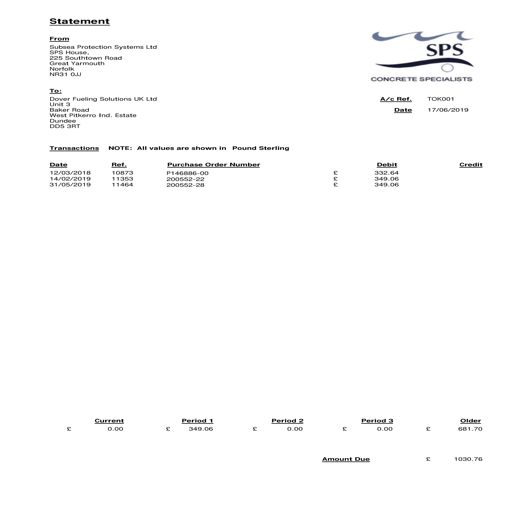

In [19]:
 dataset[0]["image"].resize((512,512))

In [20]:
dataset[0]['json']

{'Closing Balance': 1030.76,
 'Transactions': [{'Amount': 332.64,
   'Balance': 332.64,
   'Date': '2018-03-12',
   'Ref': '10873',
   'Type': 'invoice'},
  {'Amount': 349.06,
   'Balance': 349.06,
   'Date': '2019-02-14',
   'Ref': '11353',
   'Type': 'invoice'},
  {'Amount': 349.06,
   'Balance': 349.06,
   'Date': '2019-05-31',
   'Ref': '11464',
   'Type': 'invoice'}]}

In [30]:
if True:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

from datasets import load_dataset
dataset = load_dataset("ikram98ai/invoice_img2json", split = "test")


==((====))==  Unsloth 2025.3.19: Fast Qwen2_5_Vl patching. Transformers: 4.51.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [42]:
from pprint import pprint 
for sample in test_dataset:
    print('Actual JSON:')
    pprint(sample['json'])
    print("\n\nPredicted JSON:")
    image = sample["image"].resize((512,512))
    extract_json(image, model, instruction1)

Actual JSON:
{'Closing Balance': 2423.6,
 'Transactions': [{'Amount': 573.41,
                   'Balance': 573.41,
                   'Date': '2023-07-05',
                   'Ref': '40000918-3',
                   'Type': 'invoice'},
                  {'Amount': 746.27,
                   'Balance': 746.27,
                   'Date': '2023-08-01',
                   'Ref': '40000918-4',
                   'Type': 'invoice'},
                  {'Amount': 1103.92,
                   'Balance': 1103.92,
                   'Date': '2023-10-03',
                   'Ref': '40003513-1',
                   'Type': 'invoice'}]}


Predicted JSON:
```json
{
  "Closing Balance": 2423.60,
  "Transactions": [
    {
      "Date": "07/01/2023",
      "Type": "IV",
      "Ref": "4000918-8",
      "Amount": 573.41,
      "Balance": 573.41
    },
    {
      "Date": "08/01/2023",
      "Type": "IV",
      "Ref": "4000918-8",
      "Amount": 746.27,
      "Balance": 746.27
    },
    {
      "Date": "10

### Saving to float16 for VLLM

In [22]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "PUT_HERE")